
# Refugee flows → a ranking‑race reel, recoloured by rank
### Your third end‑to‑end project with **gradient‑sankey** — built *com todo cuidado e carinho* 💙

Welcome back! 👋 This is the **third** lesson in our onboarding series, and the one where the
library shows off its most cinematic trick: **dynamic colours by rank**. Every frame, the node at
**#1 turns red** and the last‑place node fades to **green** — the leaderboard *literally changes
colour* as countries rise and fall.

We'll reproduce, **end to end**, the **forced‑displacement ranking‑race reel**: real
**UNHCR** data flowing from **origin countries → countries of asylum**, animated decade by decade as
the world's refugee crises churn — Afghanistan and Iraq, then Syria, then Venezuela and Ukraine.

> The two earlier tutorials (`tutorial_stablecoins.ipynb`, `tutorial_nvidia_income.ipynb`) taught the
> tidy `[time, source, target, value]` contract, the dynamic top‑N, and the "Others" bucket. Here we
> reuse all of that and add the two new ideas: **bilateral flows** (origin → host, not a waterfall)
> and **`dynamic_color_mode="ranking"`**.

---

### What we'll build

A **ranking race** with two columns: on the **left**, refugee **origin countries** (Afghanistan,
Syria, Ukraine, Venezuela, …); on the **right**, the **countries of asylum** that host them (Iran,
Turkey, Pakistan, Colombia, …). Ribbons flow origin → host, their width is the number of people, and
**every frame is one year**. A neutral **"Others"** host soaks up the long tail of smaller asylum
countries, and a footer chart tracks either the **total people displaced** (stock) or the **net new
displacement each year** (flow).

The star of the show: as the race reorders each year, **`dynamic_color_mode="ranking"`** repaints
every node by its *live* rank using the `RdYlGn_r` colormap — **#1 = red, last = green** — so the
biggest crisis of each year is unmistakable.

### Learning outcomes

1. Call the **free UNHCR Refugee Data Finder API** (no key) and read its raw JSON.
2. Understand **stock vs flow**: people *currently* displaced vs the *net new* displacement per year.
3. Build a tidy long‑form DataFrame `[year, origin, host, value]` for **bilateral** flows.
4. Implement the **global top‑N hosts** and the clever **host‑side "Others" = origin total −
   named hosts**, and understand *why* it keeps each origin's total (and the ranking) honest.
5. Drive `gradient_sankey` with **`dynamic_color_mode="ranking"` + `RdYlGn_r`**, the people axis
   (`value_prefix=""`), `layer0_label_side`, and the **stock/flow overlay** with `overlay_band`.

> **This notebook is fully self‑contained.** It clones‑and‑runs from the gradient‑sankey repo: it
> imports only `gradient_sankey` (the committed module at the repo root), the Python standard library,
> and the pip packages `pandas` and `requests`. Every fetch and every helper is **inlined below as a
> teaching step**, so you can read the whole ETL pipeline — the UNHCR fetch, the bilateral flow
> builder, the top‑N hosts + "Others" reconstruction and the stock‑vs‑flow overlay — end to end. 💙



## 1 · Setup & install

The library lives in this repo as a single module, `gradient_sankey.py`, at the **repo root**. We add
the repo root to `sys.path` so we always get the **local** copy with the newest features.

```bash
pip install gradient-sankey pandas requests   # the public packages
# this notebook uses the LOCAL repo copy of gradient_sankey via sys.path (see below)
```

> ⚠️ **Heads‑up — local‑only features.** This reel leans on a few capabilities that are present in
> this **local** copy of `gradient_sankey.py` but may not be on your **published pip package** — check
> your installed `gradient-sankey` version if a knob below is missing:
> - **`dynamic_color_mode="ranking"`** with **`dynamic_colormap="RdYlGn_r"`** — recolour every node
>   by its live rank each frame (the whole point of this lesson),
> - pinning a node named exactly **`"Others"`** to the **bottom** of the race **and** keeping it a
>   fixed neutral colour even under dynamic colouring,
> - **hiding zero‑value nodes** (so an origin/host can drop out and disappear cleanly),
> - the **layer‑total value axis** (`yaxis_node`) with **`value_prefix=""`** (people, not dollars),
>   plus **`yaxis_gap`** and **`layer0_label_side`**,
> - the **`overlay_band`** control (push the footer line chart lower, clear of the Sankey).
>
> Importing the local module via `sys.path` (below) makes all of these work today. 🎁

We only need `requests` + `pandas` for the data, and the library for the visuals. Rendering an
**MP4** also needs **FFmpeg** on your PATH — but the still frames (`save_frame`) need nothing extra,
so the notebook stays runnable even without FFmpeg.


In [1]:
import os, sys, json, pathlib

# --- import the LOCAL gradient_sankey from the repo root (committed module) ---
# This notebook lives in notebooks/, so the repo root is one level up.
REPO_ROOT = os.path.abspath("..")          # notebooks/  ->  repo root
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import requests
import pandas as pd
from IPython.display import Image, display

import gradient_sankey as gs
from gradient_sankey import SankeyRaceMultiLayerParallel as Sankey

# where we'll drop the rendered stills / sample clip (kept out of the repo root)
ASSETS = os.path.abspath("gallery_assets"); os.makedirs(ASSETS, exist_ok=True)

# a LOCAL, gitignored cache for the UNHCR downloads, so a re-run is instant.
# Re-fetching from the UNHCR API on a clean run is fine (free, no key).
CACHE = pathlib.Path(os.path.abspath(".nbcache")); CACHE.mkdir(parents=True, exist_ok=True)

def show(path, w=900):
    return Image(filename=path, width=w)

print("gradient-sankey version:", gs.__version__)
print("pandas:", pd.__version__)
print("cache ->", CACHE)


gradient-sankey version: 1.2.2
pandas: 3.0.1
cache -> C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\.nbcache



## 2 · A 2‑minute UNHCR primer — and *stock vs flow*

The UN Refugee Agency publishes the **[Refugee Data Finder](https://www.unhcr.org/refugee-statistics/)**,
backed by a **free, key‑less** API. We need exactly one endpoint:

```
GET https://api.unhcr.org/population/v1/population/?coo=<ISO3>&coa_all=true&yearFrom=..&yearTo=..
```

- **`coo`** = *country of origin* (ISO‑3 code, e.g. `AFG`, `UKR`). One call returns that origin's
  people across **all** countries of asylum, for the whole year range — cheap and tidy.
- **`coa_all=true`** = give me *every* country of asylum (`coa`), not just one.
- The response is **paginated** (`maxPages`); we loop pages and stitch them together.

Each row is a `(year, origin, asylum‑country)` triple with several population figures. The ones we
care about:

| Field | Meaning |
|---|---|
| `refugees` | recognised refugees living across the border |
| `asylum_seekers` | people whose claims are still pending |
| `oip` | "others in need of international protection" — **captures e.g. Venezuelans displaced abroad** |
| `idps` | **internally** displaced (still inside their own country) — we **exclude** these |

> ### Stock vs flow — the idea behind the overlay
> UNHCR reports a **stock**: the number of people displaced **and still abroad** at year‑end. That's
> cumulative — Syrians who fled in 2013 are still counted in 2020. The **flow** is the *net new*
> displacement in a single year, which we get as the **year‑over‑year change of the stock**:
> $$\text{flow}_t = \text{stock}_t - \text{stock}_{t-1}.$$
> Our footer chart can show either; the reel's `--flow` switch picks the per‑year flow.
>
> ⚠️ **The flow can be *negative*.** In big **return** years — Afghans heading home after 2002, say —
> the stock *drops*, so $\text{flow}_t < 0$ and the footer line **dips below zero**. That's correct, not
> a bug: a negative flow means more people went home (or stopped being counted) than were newly
> displaced that year. We print both the largest and the smallest (most negative) flow below so you can
> see it.



## 3 · Scraping the data

We fetch a **handful of origin countries** across a wide span so we can watch the crises change era.
Each origin is one paginated query, **disk‑cached** under a local, gitignored `.nbcache/` folder
(`unhcr_<ISO3>_<y0>_<y1>.json`) — so a re‑run is instant, and a fresh clone simply fetches its own
copy once from the free UNHCR API.

The `fetch_origin` helper does the paging: loop pages until `page >= maxPages`, collect `items`,
write the JSON to disk.

> 🪶 To keep the lesson light we pick a **small curated origin set** (the ones that define each era)
> and the full year range so the stills can show 1980s Afghanistan *and* 2022 Ukraine. You can widen
> the `ORIGINS` dict below to taste; the logic is identical.


In [2]:
UNHCR = "https://api.unhcr.org/population/v1/population/"
UA = {"User-Agent": "gradient-sankey-refugee-reel/1.0 (+github.com/FG-SC/gradient-sankey)"}

# A small curated set of origins whose crises span the whole arc (Afghanistan/Iraq era
# -> Syria era -> Venezuela/Ukraine era). Widen this dict to taste; the logic is identical.
ORIGINS = {
    "AFG": "Afghanistan", "SYR": "Syria", "UKR": "Ukraine",
    "VEN": "Venezuela",   "IRQ": "Iraq",  "SOM": "Somalia",
}
Y0, Y1 = 1980, 2024      # data reaches back to ~1979

def fetch_origin(iso, y0=Y0, y1=Y1):
    """All (year, asylum-country) rows for one origin, across all pages (disk-cached).
    One origin -> all asylum countries, all years; loop pages until page >= maxPages."""
    cf = CACHE / f"unhcr_{iso}_{y0}_{y1}.json"
    if cf.exists():
        return json.loads(cf.read_text(encoding="utf-8"))
    rows, page = [], 1
    while True:
        p = dict(limit=2000, page=page, yearFrom=y0, yearTo=y1, coo=iso, coa_all="true")
        r = requests.get(UNHCR, params=p, headers=UA, timeout=60)
        r.raise_for_status()
        d = r.json()
        rows += d.get("items", [])
        if page >= int(d.get("maxPages", 1) or 1):
            break
        page += 1
    cf.write_text(json.dumps(rows), encoding="utf-8")
    return rows

# fetch every curated origin (cached after the first run)
raw = {iso: fetch_origin(iso) for iso in ORIGINS}
print("fetched origins:", {iso: len(rows) for iso, rows in raw.items()})


fetched origins: {'AFG': 2459, 'SYR': 2248, 'UKR': 1219, 'VEN': 707, 'IRQ': 2778, 'SOM': 2924}



Let's look at one **raw row** so the field shapes are concrete. Notice that the numeric fields can
arrive as a real `int`, the string `"0"`, or `"-"` (missing) — so we'll need a tiny coercion helper.


In [3]:
# one raw datapoint, so the API shape is concrete (Afghanistan, earliest year)
example = raw["AFG"][0]
print(json.dumps(example, indent=2))
print("\nnote the numeric fields:")
for k in ("refugees", "asylum_seekers", "oip", "idps"):
    v = example.get(k)
    print(f"  {k:>16} = {v!r:>10}   (type {type(v).__name__})")


{
  "year": 1980,
  "coo_id": 2,
  "coo_name": "Afghanistan",
  "coo": "AFG",
  "coo_iso": "AFG",
  "coa_id": 91,
  "coa_name": "Iran (Islamic Rep. of)",
  "coa": "IRN",
  "coa_iso": "IRN",
  "refugees": 300000,
  "asylum_seekers": "0",
  "returned_refugees": "0",
  "idps": "0",
  "returned_idps": "0",
  "stateless": "0",
  "ooc": "0",
  "oip": "-",
  "hst": "0"
}

note the numeric fields:
          refugees =     300000   (type int)
    asylum_seekers =        '0'   (type str)
               oip =        '-'   (type str)
              idps =        '0'   (type str)



### Why we add `oip`, and why we drop `coo == coa`

Two modelling choices that keep the flows honest:

- **`value = refugees + asylum_seekers + oip`.** Adding `oip` ("others in need of international
  protection") is what lets **Venezuela** show up properly — millions of Venezuelans abroad are
  counted there rather than as formal refugees.
- **Drop rows where `coo == coa`.** When the origin equals the asylum country, those are
  **internally displaced people (IDPs)** — still *inside* their own country. We want **cross‑border**
  flows only, so we skip them.


In [4]:
def _num(x) -> int:
    """UNHCR numeric fields arrive as ints, '0', or '-' (missing). Coerce to int."""
    try:
        return int(x)
    except (TypeError, ValueError):
        return 0

# Trim the UN's long official asylum-country names to something a label can show.
HOST_SHORT = {
    "United States of America": "USA", "Iran (Islamic Rep. of)": "Iran",
    "United Republic of Tanzania": "Tanzania", "United Rep. of Tanzania": "Tanzania",
    "United Kingdom of Great Britain and Northern Ireland": "UK", "United Kingdom": "UK",
    "Russian Federation": "Russia", "Syrian Arab Rep.": "Syria",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Bolivarian Republic of Venezuela": "Venezuela", "Rep. of Korea": "South Korea",
    "Dem. Rep. of the Congo": "DR Congo", "Türkiye": "Turkey", "Turkey": "Turkey",
}
def _short(name):
    return HOST_SHORT.get(name, name)

# build the raw long-form records: (year, origin, host, value) for CROSS-BORDER people
recs = []
for iso, name in ORIGINS.items():
    for it in raw[iso]:
        if it.get("coo_iso") == it.get("coa_iso"):
            continue                                          # skip IDPs (within-country)
        val = _num(it.get("refugees")) + _num(it.get("asylum_seekers")) + _num(it.get("oip"))
        if val <= 0:
            continue
        recs.append((int(it["year"]), name, _short(it["coa_name"]), val))

raw_long = pd.DataFrame(recs, columns=["year", "origin", "host", "value"])
raw_long = raw_long.groupby(["year", "origin", "host"], as_index=False)["value"].sum()
raw_long["value"] /= 1e6                                      # people -> millions
print(f"{len(raw_long)} (year, origin, host) rows, {raw_long.year.min()}-{raw_long.year.max()}")
raw_long.head(8)


12142 (year, origin, host) rows, 1980-2024


,year,origin,host,value
0,1980,Afghanistan,Iran,0.300000
1,1980,Afghanistan,Italy,0.000191
2,1980,Afghanistan,Pakistan,1.428230
3,1980,Afghanistan,Turkey,0.005000
4,1980,Afghanistan,United Arab Emirates,0.001500
5,1980,Iraq,Iran,0.030000
6,1980,Iraq,Italy,0.000098
7,1980,Iraq,Lebanon,0.001000



## 4 · Exploring the data — and its quirks

Real displacement data is full of history. A quick look reveals the things our cleaning step (and the
story) must respect:

- **Crises that didn't exist early.** The series reaches back to **~1979**, but **Syria** barely
  registers before 2012, **Ukraine** before 2014/2022, and **Venezuela** before ~2016. The chart must
  let an origin **appear** mid‑story rather than fake a value.
- **Venezuela lives in `oip`.** Without adding `oip` (previous step), Venezuela's millions would
  almost vanish — they're "others in need of protection", not formal refugees.
- **Palestine is mostly absent here.** Palestinians under **UNRWA**'s mandate aren't in this
  UNHCR population dataset, so Palestine looks far smaller than reality. (You could add `PSE` to
  `ORIGINS` with that caveat; we leave it out of our small set to avoid confusion.)

Let's see *when* each origin first becomes significant, and how the top origin changes by era.


In [5]:
# when each origin first crosses 0.1M people displaced abroad
first_big = (raw_long[raw_long.value > 0.1]
             .groupby("origin")["year"].min()
             .reindex(list(ORIGINS.values())))
print("First year each origin exceeds 0.1M displaced abroad:")
display(first_big)

# the top origin by era — watch the crisis baton pass across decades
print("Largest origin (by people displaced abroad) in sampled years:")
for y in (1985, 1995, 2007, 2015, 2022, 2024):
    sub = raw_long[raw_long.year == y]
    if sub.empty:
        continue
    top = sub.groupby("origin")["value"].sum().nlargest(3)
    print(f"  {y}: " + ", ".join(f"{k} {v:.1f}M" for k, v in top.items()))


First year each origin exceeds 0.1M displaced abroad:


origin
Afghanistan    1980
Syria          2012
Ukraine        2014
Venezuela      2018
Iraq           1985
Somalia        1988
Name: year, dtype: int64

Largest origin (by people displaced abroad) in sampled years:
  1985: Afghanistan 4.7M, Iraq 0.4M, Syria 0.0M
  1995: Afghanistan 2.7M, Iraq 0.7M, Somalia 0.6M
  2007: Afghanistan 3.1M, Iraq 2.3M, Somalia 0.5M


  2015: Syria 5.1M, Afghanistan 2.9M, Somalia 1.2M
  2022: Syria 6.7M, Venezuela 6.6M, Afghanistan 6.0M
  2024: Venezuela 7.6M, Afghanistan 6.2M, Syria 6.1M



## 5 · Cleaning + the clever bits

This is the heart of the project — and it's where the **bilateral** twist lives. Unlike a waterfall
(NVIDIA) or a single dynamic top‑N (stablecoins), here we keep a **fixed set of top hosts** and fold
*everything else* into a host‑side **"Others"** computed per origin. Two steps.

### 5.1 · Top‑N hosts, globally

We pick the **top‑`N_HOSTS`** countries of asylum by their **all‑time total** across our origins.
These named hosts become the right‑hand column; every other destination becomes "Others".


In [6]:
N_HOSTS = 10        # keep 10 for a compact right column (raise it to widen the hosts)

total_by   = raw_long.groupby(["year", "origin"])["value"].sum()           # each origin's full total
top_hosts  = raw_long.groupby("host")["value"].sum().nlargest(N_HOSTS).index.tolist()
print(f"Top {N_HOSTS} asylum countries (all-time, across our origins):")
print("  " + ", ".join(top_hosts))


Top 10 asylum countries (all-time, across our origins):
  Pakistan, Iran, Turkey, Germany, Colombia, Jordan, Lebanon, Kenya, Peru, Ethiopia



### 5.2 · The clever bit — host‑side **"Others" = origin total − named hosts**

Here's the subtle part. We only *draw* the top‑N hosts, but an origin sends people to **many** more
countries than those. If we simply dropped the unnamed hosts, an origin whose refugees scatter widely
(hello, **Venezuela** across Latin America) would look artificially *small*, and the **ranking would
lie**.

So for each `(year, origin)` we add a single **"Others"** host equal to:

$$\text{Others} = \max\!\big(\underbrace{\text{origin's total to ALL hosts}}_{\text{total\_by}} - \underbrace{\text{origin's total to the NAMED hosts}}_{\text{shown\_by}},\ 0\big).$$

This keeps **each origin's grand total intact**, so the left‑column ranking (who is the biggest origin
this year) is **honest**. We name the node exactly **`"Others"`** because the library **pins that name
to the bottom** of the race and keeps it a **neutral colour** even under dynamic colouring.


In [7]:
shown    = raw_long[raw_long.host.isin(top_hosts)].copy()
shown_by = shown.groupby(["year", "origin"])["value"].sum().reindex(total_by.index, fill_value=0.0)
others   = (total_by - shown_by).clip(lower=0)                 # origin total - named hosts, >= 0

orows = [{"year": y, "origin": o, "host": "Others", "value": float(v)}
         for (y, o), v in others.items() if v > 1e-9]
df = pd.concat([shown, pd.DataFrame(orows)], ignore_index=True)

# layers: origins on the LEFT (in our curated order), hosts on the RIGHT, "Others" pinned last
origins = [n for n in ORIGINS.values() if n in set(df.origin)]
hosts = (shown.groupby("host")["value"].sum().reindex(top_hosts)
         .sort_values(ascending=False).index.tolist()) + ["Others"]
LAYERS = [origins, hosts]

print("origins (left) :", origins)
print("hosts   (right):", hosts)

# sanity check: with 'Others' added, each (year, origin) total is preserved.
# We check VENEZUELA -- whose refugees scatter widely across Latin America, so the
# "Others" bucket recovers a big chunk its named-hosts-only total would miss (the
# undercount story that motivates this whole section).
check_origin = "Venezuela"
check_year = 2024
named_only = shown[shown.year == check_year].groupby("origin")["value"].sum()
with_others = df[df.year == check_year].groupby("origin")["value"].sum()
print(f"\n{check_year}: {check_origin} total — named hosts only = "
      f"{named_only.get(check_origin, 0):.2f}M  vs  with Others = {with_others.get(check_origin, 0):.2f}M")
df.head()


origins (left) : ['Afghanistan', 'Syria', 'Ukraine', 'Venezuela', 'Iraq', 'Somalia']
hosts   (right): ['Pakistan', 'Iran', 'Turkey', 'Germany', 'Colombia', 'Jordan', 'Lebanon', 'Kenya', 'Peru', 'Ethiopia', 'Others']

2024: Venezuela total — named hosts only = 4.48M  vs  with Others = 7.61M


,year,origin,host,value
0,1980,Afghanistan,Iran,0.30000
1,1980,Afghanistan,Pakistan,1.42823
2,1980,Afghanistan,Turkey,0.00500
3,1980,Iraq,Iran,0.03000
4,1980,Iraq,Lebanon,0.00100



### 5.3 · Node colours — placeholders, on purpose

Here's the twist that makes this the **dynamic‑colour** lesson: the base node colours **don't matter**
for the animation. We pass a flat gray for everything, because **`dynamic_color_mode="ranking"`**
will **repaint every node by its live rank each frame**. The one exception is **"Others"**, which the
library keeps neutral regardless. (The base colours *are* used by the static `save_frame` stills,
which can't do dynamic colouring — more on that below.)


In [8]:
# Base colours are placeholders -- dynamic_color_mode="ranking" recolours every node
# by its live rank each frame (that is the whole point of this demo).
node_colors = {n: "#888888" for n in origins + hosts}
node_colors["Others"] = "#6B7280"     # neutral gray; the lib keeps it fixed under dynamic modes
print(f"{len(node_colors)} placeholder colours (gray); rank decides the real colour at render time")


17 placeholder colours (gray); rank decides the real colour at render time



## 6 · The stock‑vs‑flow overlay

The footer chart is a **bar‑chart‑race** style line of the people displaced, one point per year. We
build **both** the *stock* (cumulative people abroad) and the *flow* (net new per year) so you can
flip between them with the `FLOW` switch below.

> ⚠️ **Heads‑up: the flow series can go negative.** Because `flow_t = stock_t − stock_{t-1}`, any year
> with a large **return home** (e.g. Afghanistan after 2002) makes the stock fall and the flow turn
> **negative**, so the footer line will **dip below zero** for that year. The print below shows the
> minimum (most negative) flow right next to the maximum so the dip is no surprise.


In [9]:
years = sorted(df["year"].unique())
total = [float(df[df.year == y]["value"].sum()) for y in years]    # stock shown each year (M)

# net NEW displacement per year = year-over-year delta of the stock
flow_series = [0.0] + [total[i] - total[i - 1] for i in range(1, len(total))]

# pick which one the overlay shows (flip to False for the cumulative stock). True = per-year flow.
FLOW = True
if FLOW:
    overlay_series = flow_series
    overlay_label, overlay_badge = "Net new displacement per year  (millions)", "PER YEAR"
else:
    overlay_series = total
    overlay_label, overlay_badge = "People displaced across borders  (millions)", "TOTAL"

xlabels = [str(y) for y in years]
print(f"stock: {total[0]:.1f}M -> {total[-1]:.1f}M   |   "
      f"biggest single-year flow: +{max(flow_series):.1f}M   |   "
      f"most negative (mass-return) flow: {min(flow_series):+.1f}M")


stock: 1.8M -> 26.6M   |   biggest single-year flow: +9.3M   |   most negative (mass-return) flow: -2.0M



## 7 · Building the visual — every knob explained

Now the fun part. We hand the tidy `df` + `LAYERS` to `from_dataframe`, then drive `animate()` with
the reel's design. Here's what each knob does in **this** reel:

| Knob | Value | Why |
|---|---|---|
| `ranking_mode` | `True` | reorder origins/hosts by value each frame — *the race* |
| `stacked_mode` | `True` | bar heights scale with people (biggest = tallest) |
| `dynamic_color_mode` | `"ranking"` ⚠️ | **repaint every node by its live rank each frame** — the star |
| `dynamic_colormap` | `"RdYlGn_r"` ⚠️ | the rank→colour map: **#1 = red → last = green** |
| `theme` | `"dark"` | the neon‑on‑black reel look |
| `link_glow` / `link_alpha` | `1` / `0.6` | soft neon glow behind the ribbons |
| `n_segments` | `100` | smooth gradients along each ribbon |
| `yaxis_node` | `origins[0]` ⚠️ | draw a value axis scaled to the **origin‑layer total** |
| `yaxis_suffix` / `value_prefix` | `"M"` / `""` ⚠️ | ticks read like `12M` — **people, not dollars** |
| `yaxis_gap` / `layer0_label_side` | `0.15` / `"right"` ⚠️ | axis hugs the origin column; names on the right |
| `overlay_series` / `overlay_x_labels` | stock‑or‑flow / years | the footer race chart |
| `overlay_band` | `(0.18, 0.56)` ⚠️ | push the line chart **lower**, clear of the Sankey |

### How rank → colour actually works 🌈

With `dynamic_color_mode="ranking"`, on **every frame** the library:
1. ranks the visible nodes by value (within the frame),
2. maps each node's rank to a position in `[0, 1]` — **rank #1 → 0.0**, last place → **1.0**,
3. samples the **`RdYlGn_r`** colormap at that position.

`RdYlGn` runs green→yellow→red; the **`_r`** reverses it to **red→yellow→green**. So the **biggest**
origin/host (rank #1, position 0.0) is **red** (alarm), and the smallest is **green** (calm). As a war
erupts, that origin climbs the ranking and *turns red on screen* — the colour **is** the story. Swap
in `"plasma"` or `"turbo"` for a different mood; **"Others" stays gray** either way.

First, build the renderer from the DataFrame — the single call that ingests everything.


In [10]:
sk = Sankey.from_dataframe(
    df=df, layers=LAYERS,
    time_col="year", source_col="origin", target_col="host", value_col="value",
    node_colors=node_colors,
)
anchor = origins[0]    # any origin identifies the left layer for the people axis
print(f"{len(sk.frames)} frames (years):", sk.frames[0]['time_label'], "->", sk.frames[-1]['time_label'])
print("value axis anchored on the origin layer of:", anchor)


45 frames (years): 1980 -> 2024
value axis anchored on the origin layer of: Afghanistan



## 8 · Render a short proof

Stills first — `save_frame()` needs **no FFmpeg**, so this always works. We render three years that
each defined an era of displacement:

- **1985** — Afghanistan dominates (Iran & Pakistan host millions after the Soviet war),
- **2022** — Ukraine erupts (Russia, Poland, Germany),
- **2024** — Venezuela's long tail and the Syrian aftermath.

> ⚠️ **One honest caveat about the stills.** `save_frame` is **static**, so it can't do the
> per‑frame **dynamic ranking colours** (those are computed *during* the animation). The stills
> therefore use our placeholder gray base colours — they prove the **layout, axis, labels and
> ranking order**, while the **red→green rank colouring** only appears in the animated clip below. The
> people axis (`yaxis_node` + `value_prefix=""`) and `layer0_label_side` *do* work in stills.


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\refugees_1985.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\refugees_1985.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\refugees_2022.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\refugees_2022.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\refugees_2024.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\refugees_2024.png


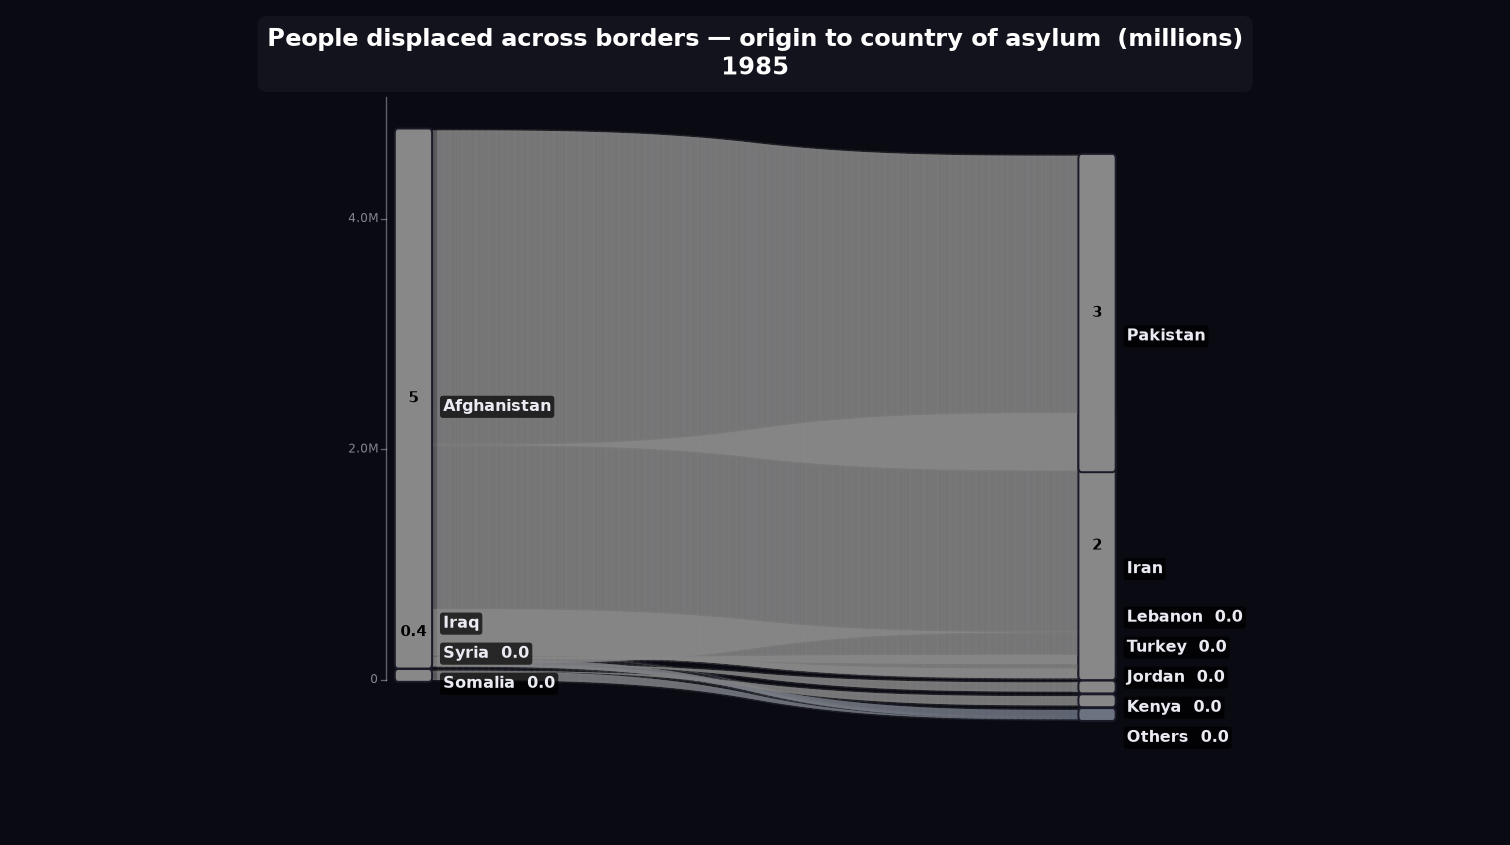

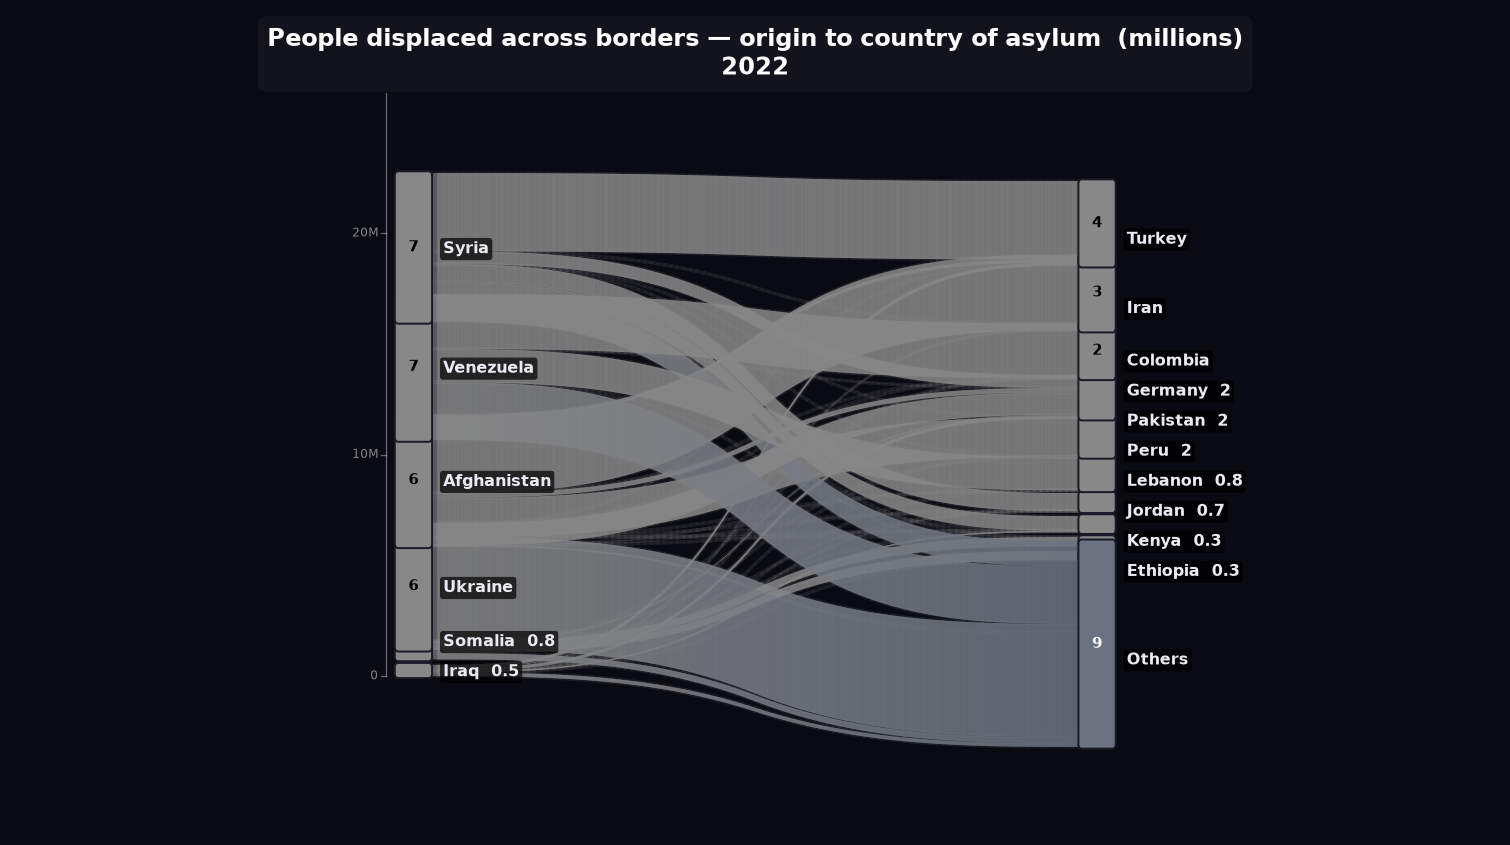

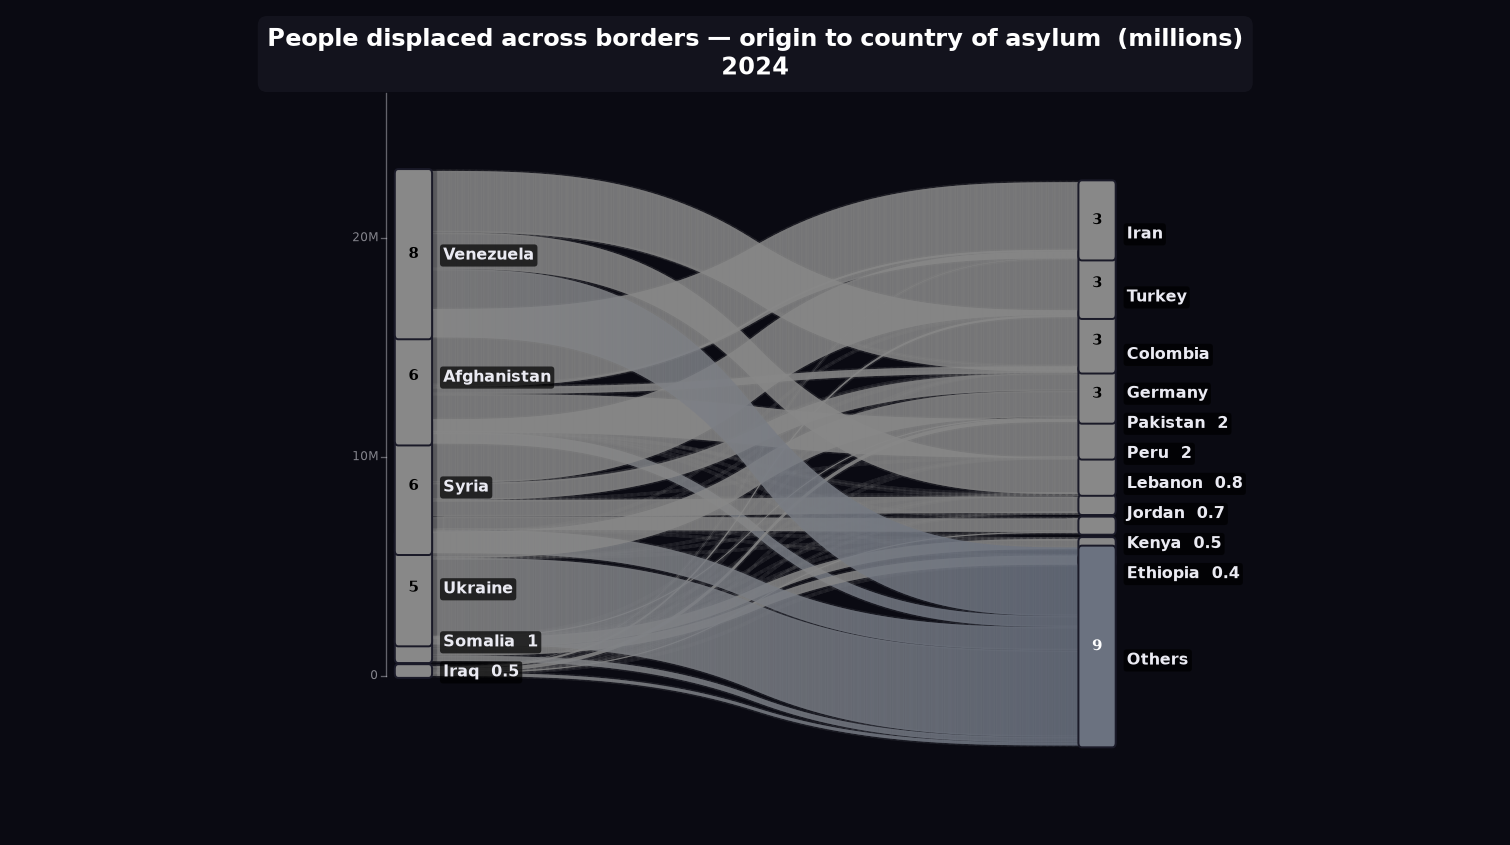

In [11]:
# the static-still design (no dynamic colour here -- that's animation-only)
still_design = dict(
    figsize=(16, 9), dpi=95, font_size=12, title_fontsize=18, padding=2.8,
    margin_top=0.16, margin_bottom=0.20,
    ranking_mode=True, stacked_mode=True,            # the race: reorder AND resize
    theme="dark", link_glow=1, link_alpha=0.6, n_segments=100,
    yaxis_node=anchor, yaxis_suffix="M",             # people axis, scaled to the origin-layer TOTAL
    yaxis_gap=0.15, layer0_label_side="right",       # axis hugs the origins; names on the right
    value_prefix="",                                 # people, not dollars (save_frame defaults to "$")
)

year_to_index = {f["time_label"]: i for i, f in enumerate(sk.frames)}
still_paths = []
for yr in ("1985", "2022", "2024"):
    if yr not in year_to_index:
        continue
    p = os.path.join(ASSETS, f"refugees_{yr}.png")
    sk.save_frame(p, frame_index=year_to_index[yr],
                  title="People displaced across borders — origin to country of asylum  (millions)",
                  **still_design)
    still_paths.append(p)
    print("saved", p)

for p in still_paths:
    display(show(p, w=1000))



### One short animation — *now* the rank colours come alive 🎬

A tiny clip to prove the motion **and** the dynamic colouring. We keep it short for speed (a few
seconds) but with the **full** reel design: dark theme, glow, the people axis, the stock/flow overlay,
and — the headline — **`dynamic_color_mode="ranking"` + `RdYlGn_r`**, so the #1 origin/host burns red
while the rest cool to green. The cell **skips gracefully** if FFmpeg isn't installed.


In [12]:
sample_mp4 = os.path.join(ASSETS, "refugees_sample.mp4")
try:
    sk.animate(
        sample_mp4,
        figsize=(16, 9), fps=24, duration_seconds=8, quality="medium", n_workers=2,
        title="People displaced across borders — origin to country of asylum  (millions)",
        font_size=12, title_fontsize=20, padding=2.8,
        margin_top=0.16, margin_bottom=0.23,
        ranking_mode=True, stacked_mode=True,
        dynamic_color_mode="ranking", dynamic_colormap="RdYlGn_r",   # <-- the star of the demo
        theme="dark", link_glow=1, link_alpha=0.6, n_segments=100,
        yaxis_node=anchor, yaxis_suffix="M", yaxis_gap=0.15, layer0_label_side="right",
        value_prefix="",                                             # people, not dollars
        overlay_series=overlay_series, overlay_x_labels=xlabels,
        overlay_label=overlay_label, overlay_color="#FFB000",
        overlay_value_suffix="M", overlay_badge=overlay_badge,
        overlay_band=(0.18, 0.56),                                   # push the line chart lower
    )
    from IPython.display import Video
    print("rendered:", sample_mp4)
    display(Video(sample_mp4, embed=True, width=900))
except Exception as e:
    print("Skipping the MP4 (FFmpeg likely not installed) — the stills above tell the story.")
    print("Reason:", repr(e))


Settings (MULTI-LAYER PARALLEL):
  - Layers: 2
  - Nodes per layer: [6, 11]
  - FPS: 24, Duration: 8s
  - Quality: medium
  - Total frames: 192
  - Gradient segments: 100
  - Positioning mode: Stacked + Ranking
  - Dynamic color mode: Ranking
  - Colormap: RdYlGn_r

Pre-computing 192 frames...


  Pre-computation: 5.29s
  Workers: 2

Rendering on 2 parallel processes...


Skipping the MP4 (FFmpeg likely not installed) — the stills above tell the story.
Reason: MemoryError((900, 1600, 3), dtype('uint8'))



### The full reel — wrap it in one function

Everything above — fetch, clean, the "Others" reconstruction, the overlay and the render — is the
whole pipeline. To produce a long, polished reel, raise the knobs you've already met: widen `ORIGINS`
(add `"SSD"`, `"COD"`, `"MMR"`, …), raise `N_HOSTS` to 12–14, and call `animate()` with a longer
`duration_seconds` (e.g. 90) and `quality="high"`. Swap `dynamic_colormap` to `"plasma"` for a
different mood — the ranking logic is unchanged.

> 💡 When you save final renders, stamp every output filename with a **big‑endian, sortable**
> date‑time prefix (`%Y-%m-%d-%Hh%M`, with `:` → `h` since it's illegal in paths) — so your renders
> always sort chronologically. 🗂️



## 9 · Recap & try it yourself

🎉 **You built the whole reel** — from raw UNHCR JSON to an animated gradient Sankey ranking race
that **recolours itself by rank** every frame.

**The pipeline, in one breath:** fetch a few origins' bilateral data (paginated, cached) → drop IDPs
& add `oip` → build long‑form `[year, origin, host, value]` → pick **top‑N hosts** → add the
host‑side **"Others" = origin total − named hosts** (keeps the ranking honest, pinned last) →
**stock vs flow** overlay (year‑over‑year delta) → `from_dataframe` → `save_frame` stills + `animate`
with **`dynamic_color_mode="ranking"` + `RdYlGn_r`**.

### 🧪 Try it yourself

1. **Other origins.** Add `"SSD": "South Sudan"`, `"COD": "DR Congo"`, `"MMR": "Myanmar"` to
   `ORIGINS` and re‑run — watch new crises enter the left column.
2. **Stock vs flow.** Set `FLOW = False` in §6 to make the footer track the cumulative **stock**
   instead of the per‑year flow — and notice how differently the story reads.
3. **A different colormap.** Swap `dynamic_colormap="RdYlGn_r"` for `"plasma"`, `"turbo"`, or
   `"viridis"` in the clip — same ranking logic, new mood. (`"Others"` stays gray.)
4. **More hosts.** Raise `N_HOSTS` to 12–14 and re‑run from §5.1 to widen the right column.
5. **Your own bilateral data.** The library only needs a tidy `[year, origin, host, value]` frame +
   `layers`. Point it at trade flows, migration, anything that goes **A → B** and ranks over time.

### 🔗 Links

- The library: `gradient_sankey.py` (repo root) · `pip install gradient-sankey`
- UNHCR Refugee Data Finder: https://www.unhcr.org/refugee-statistics/  (free, no API key)
- UNHCR population API: https://api.unhcr.org/population/v1/population/  (free, no key, paginated)
- Companion tutorials: `notebooks/02_tutorial_stablecoins.ipynb` and
  `notebooks/01_tutorial_nvidia_income.ipynb`

> 💡 Remember: **`dynamic_color_mode="ranking"` + `RdYlGn_r`**, pinning **"Others"** (and keeping it
> neutral under dynamic colour), hiding zero nodes, the people axis (`value_prefix=""`), `yaxis_gap`,
> `layer0_label_side` and `overlay_band` are available in **this local copy** — check your installed
> `gradient-sankey` version if any are missing. Either way, importing the local module via `sys.path`
> (as we did in §1) makes everything just work. 💙

*Built com todo cuidado e carinho. Data: UNHCR Refugee Data Finder (free, no API key). Happy hacking!*
